### Ilustración de la interpretabilidad cuando la *feature* 4077 del SAE predice BSPA82

Mostrar cómo la *feature* **4077** concreta del SAE estándar detecta la Board State Property **BSPA82 = casilla A8 con pieza del oponente, en perspectiva del jugador**.

### 1. Setup e imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

# project_root apunta a la carpeta sae/ (este notebook cuelga de
# sae/metrics/03_metrics_implementation/standar/interpretabilidad/)
project_root = Path('../../../..').resolve()
repo_root = project_root.parent          # raiz del repo (othello_world)
for p in (str(repo_root), str(project_root)):
    if p not in sys.path:
        sys.path.insert(0, p)

from sae.models.sae import SparseAutoencoder
from sae.tools.experiment_utils import get_metrics_dir
from sae.tools.naming_utils import get_checkpoint_dir, get_model_name, get_extras_id
from sae.tools.bsp_identifier import identificador
from data.othello import OthelloBoardState

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'project_root (sae/): {project_root}')

Device: cuda
project_root (sae/): C:\Users\Esposa\Documents\Repos\othello_world\sae


### 2. Metadata del experimento
Se evaluará el modelo de 100.000 partidas ex4 evaluado con Coverage

In [2]:
NAMING_META = {
    'variante': 'standard',          # arquitectura del SAE
    'tecnica': 'p-annealing',        # Lp^p con p decreciente
    'capa': 6,                       # bloque 6 de OthelloGPT
    'juegos': 100000,                # partidas de entrenamiento
    'base_path': 'C:\\Users\\Esposa\\Documents\\Repos\\sae-othello-gpt',
    'experiment_base_path': str(project_root / 'experiments'),
    'extras': {
        'expansion': 16,
        'sparsity_coef': 5e-1,
        'epochs': 200,
        'early_stopping': False,
        'learning_rate': 1e-3,
        'p_start': 1.0,
        'p_end': 0.2,
        'n_sparsity_updates': 10,
        'anneal_start': 40000,
        'batch_size': 2048,
        'warmup_steps': 8000,
        'sparsity_warmup_steps': 16000,
        'estimated_epochs': 200,
    },
}

# Parametros fijos del ejemplo
FEATURE = 4077          # feature del SAE bajo estudio
BSP     = 'BSPA82'      # casilla A8, pieza del oponente, perspectiva jugador
CASILLA = 'A8'
A8_IJ   = (0, 7)        # A8 -> fila A (i=0), columna 8 (j=7) en el tablero 8x8

# Formato con coma decimal para las etiquetas de la figura
def fmt(x, d=4):
    return f'{x:.{d}f}'.replace('.', ',')

print('Metadata lista. Feature:', FEATURE, '| BSP:', BSP, '| casilla:', CASILLA)

Metadata lista. Feature: 4077 | BSP: BSPA82 | casilla: A8


### PARTE 1: Exploración para elegir el tablero a mano

Se cargan los resultados de Coverage ya guardados, el SAE y las activaciones
del conjunto de evaluación, se reconstruye **una** partida y se imprimen una parte de sus tableros

#### 3. Cargar `coverage_player.npz` y extraer los datos de BSPA82

In [3]:
checkpoint_dir = get_checkpoint_dir(
    NAMING_META['base_path'], NAMING_META['variante'],
    NAMING_META['tecnica'], NAMING_META['capa'], NAMING_META['juegos'],
)
extras_id = get_extras_id(checkpoint_dir, NAMING_META['extras'])

metrics_dir = get_metrics_dir(
    NAMING_META['experiment_base_path'], NAMING_META['variante'],
    NAMING_META['tecnica'], NAMING_META['capa'], NAMING_META['juegos'],
    extras_id=extras_id,
)
npz_path = metrics_dir / 'coverage_player.npz'
print('Cargando:', npz_path)

cov = np.load(npz_path, allow_pickle=True)
best_features   = cov['best_features']
best_thresholds = cov['best_thresholds']
best_f1s        = cov['best_f1s']
bsp_names       = list(cov['bsp_names'])

# Localizar BSPA82 y leer (sin recalcular nada) su feature, umbral relativo y F1
bsp_idx     = bsp_names.index(BSP)
feature_bsp = int(best_features[bsp_idx])
t_rel       = float(best_thresholds[bsp_idx])   # umbral relativo t
f1_bsp      = float(best_f1s[bsp_idx])

assert feature_bsp == FEATURE, f'Se esperaba feature {FEATURE}, pero el .npz dice {feature_bsp}'

print(f'\n{BSP}  (indice {bsp_idx} en bsp_names)')
print(f'  feature ganadora : {feature_bsp}')
print(f'  umbral relativo t: {t_rel}')
print(f'  F1               : {f1_bsp:.4f}')

Cargando: C:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_p-annealing_standard\100000games\ex4\metrics\coverage_player.npz

BSPA82  (indice 15 en bsp_names)
  feature ganadora : 4077
  umbral relativo t: 0.20000000298023224
  F1               : 0.8709


### 4. Cargar el SAE

In [4]:
input_dim, hidden_dim = 512, 8192

model_name = get_model_name(
    NAMING_META['variante'], NAMING_META['tecnica'], NAMING_META['capa'],
    NAMING_META['juegos'], 'final', extras_id=extras_id,
)
model_path = checkpoint_dir / model_name

sae = SparseAutoencoder(input_dim, hidden_dim).to(device)
checkpoint = torch.load(model_path, map_location=device, weights_only=False)
sae.load_state_dict(checkpoint['model_state_dict'])
sae.eval()

print('SAE cargado desde:')
print(' ', model_path)
print(f'  {input_dim} -> {hidden_dim}  ({hidden_dim/input_dim:.0f}x)')

SAE cargado desde:
  C:\Users\Esposa\Documents\Repos\sae-othello-gpt\layer_06\models\sae_standard\sae_p-annealing_standard\100000games\sae_standard_p-annealing_l6_100000g_ex4_final.pt
  512 -> 8192  (16x)


### 5. Umbral efectivo de la *feature* 4077

El `.npz` guarda el umbral **relativo** `t`; el umbral **efectivo** es
`t · f_max`, donde `f_max` es la activación máxima de la *feature* 4077 sobre
todo el conjunto de evaluación. 

In [5]:
activations_path = project_root / 'activations' / 'data' / 'layer6_2000games.npy'
activations = np.load(activations_path)          # (118000, 512) = 2000 partidas x 59 estados
N_MOVES = 59
n_games = activations.shape[0] // N_MOVES
print(f'Activaciones: {activations.shape}  ->  {n_games} partidas x {N_MOVES} estados')

# f_max de la feature 4077 sobre TODO el conjunto (columna 4077 del encoder)
with torch.no_grad():
    acts_t = torch.from_numpy(activations).float().to(device)
    feat_col_all = sae.encode(acts_t)[:, FEATURE]      # (118000,)
    f_max = feat_col_all.max().item()
del acts_t
torch.cuda.empty_cache()

umbral_efectivo = t_rel * f_max
print(f'\nf_max[{FEATURE}]       = {f_max:.4f}')
print(f'umbral efectivo   = t * f_max = {t_rel} * {f_max:.4f} = {umbral_efectivo:.4f}')

Activaciones: (118000, 512)  ->  2000 partidas x 59 estados

f_max[4077]       = 5.4927
umbral efectivo   = t * f_max = 0.20000000298023224 * 5.4927 = 1.0985


### 6. Reconstruir UNA partida y calcular la activación de la *feature*

`get_game_data` reconstruye los 59 estados de una partida con la lógica de
Li et al. (`OthelloBoardState`). La activación de la *feature* 4077 en cada
estado se toma de las activaciones ya extraídas (fila `game*59 + move`).

In [6]:
games_path = project_root / 'activations' / 'data' / 'games_2000.txt'
with open(games_path) as fh:
    games_lines = fh.read().strip().split('\n')

_game_cache = {}

def get_game_data(game_idx):
    # Devuelve (boards, colors, feat_acts) para una partida:
    #   boards[m]    : tablero 8x8 (1=negra, -1=blanca, 0=vacia) tras el movimiento m
    #   colors[m]    : color del jugador que jugo el movimiento m (perspectiva 'mio')
    #   feat_acts[m] : activacion de la feature 4077 en ese estado
    if game_idx in _game_cache:
        return _game_cache[game_idx]

    moves = [int(m) for m in games_lines[game_idx].split()]
    board = OthelloBoardState()
    boards, colors = [], []
    for move in moves:
        colors.append(board.next_hand_color)   
        board.update([move])
        boards.append(board.state.copy())      
    boards = boards[:N_MOVES]
    colors = colors[:N_MOVES]

    rows = slice(game_idx * N_MOVES, game_idx * N_MOVES + N_MOVES)
    with torch.no_grad():
        feats = sae.encode(torch.from_numpy(activations[rows]).float().to(device))
    feat_acts = feats[:, FEATURE].cpu().numpy()

    _game_cache[game_idx] = (boards, colors, feat_acts)
    return _game_cache[game_idx]


def bsp_a82(board, color):
    # Valor de BSPA82 usando el identificador canonico del proyecto
    return bool(identificador(board, color)[BSP])


# Partida a explorar (cambia el indice para revisar otra partida)
GAME_IDX = 0
boards, colors, feat_acts = get_game_data(GAME_IDX)
print(f'Partida {GAME_IDX}: {len(boards)} estados reconstruidos '
      f'| activaciones feature {FEATURE} listas')

Partida 0: 59 estados reconstruidos | activaciones feature 4077 listas


### 7. Imprimir los estados (movimientos 40 a 43)

Para cada estado se muestran:
- la cuadrícula, el turno y el conteo de fichas, si BSPA82 es verdadera y la
- activación de la *feature* 4077 frente al umbral efectivo.

In [7]:
SIMB = {1: '●', -1: '○', 0: '·'}   # negra / blanca / vacia

def imprimir_estado(idx, boards, colors, feat_acts, umbral):
    b, c = boards[idx], colors[idx]
    act = float(feat_acts[idx])
    verdadera = bsp_a82(b, c)
    supera = act > umbral

    n_negras = int((b == 1).sum())
    n_blancas = int((b == -1).sum())
    persp = 'Negras' if c == 1 else 'Blancas'

    print('=' * 44)
    print(f'ESTADO idx={idx}  (movimiento nº {idx + 1} de la partida)')
    print('-' * 44)
    print('    1 2 3 4 5 6 7 8')
    filas = 'ABCDEFGH'
    for i in range(8):
        fila = ' '.join(SIMB[int(b[i, j])] for j in range(8))
        marca = '  <- A8' if i == 0 else ''
        print(f'  {filas[i]} {fila}{marca}')
    print(f'  Turno: {persp}')
    print(f'  Fichas -> negras: {n_negras} | blancas: {n_blancas} | total: {n_negras + n_blancas}')
    print(f'  {BSP} (A8 = pieza del oponente): {"VERDADERA" if verdadera else "falsa"}')
    print(f'  Activacion feature {FEATURE}: {act:.4f}')
    print(f'  ¿Supera umbral efectivo ({umbral:.4f})?: {"SI" if supera else "no"}'
          f'  ->  prediccion {"VERDADERA" if supera else "falsa"}')

print(f'Partida {GAME_IDX} | umbral efectivo = {umbral_efectivo:.4f}\n')
for idx in range(39, 43):          
    imprimir_estado(idx, boards, colors, feat_acts, umbral_efectivo)

Partida 0 | umbral efectivo = 1.0985

ESTADO idx=39  (movimiento nº 40 de la partida)
--------------------------------------------
    1 2 3 4 5 6 7 8
  A ○ ○ ○ · ● ● · ●  <- A8
  B ○ ○ ○ ○ ● ● ● ●
  C · ○ ○ ○ ● ● ● ●
  D ○ ○ · ● ● ● ● ●
  E · · ○ ○ ● ● ● ○
  F · ● · ○ ● ○ ○ ○
  G ● · · ● · ○ · ○
  H · · · · · · · ·
  Turno: Blancas
  Fichas -> negras: 23 | blancas: 21 | total: 44
  BSPA82 (A8 = pieza del oponente): VERDADERA
  Activacion feature 4077: 2.4894
  ¿Supera umbral efectivo (1.0985)?: SI  ->  prediccion VERDADERA
ESTADO idx=40  (movimiento nº 41 de la partida)
--------------------------------------------
    1 2 3 4 5 6 7 8
  A ○ ○ ○ · ● ● · ●  <- A8
  B ○ ○ ○ ○ ● ● ● ●
  C · ○ ○ ○ ● ● ● ●
  D ○ ○ · ● ● ● ● ●
  E · ● ● ● ● ● ● ○
  F · ● · ○ ● ○ ○ ○
  G ● · · ● · ○ · ○
  H · · · · · · · ·
  Turno: Negras
  Fichas -> negras: 26 | blancas: 19 | total: 45
  BSPA82 (A8 = pieza del oponente): falsa
  Activacion feature 4077: 0.8195
  ¿Supera umbral efectivo (1.0985)?: no  ->  pred

### PARTE 2: Figura final

Eligir a mano, a partir de la impresión anterior, **un estado con BSPA82 verdadera y otro con falsa** 

In [8]:
ESTADO_VERDADERO = dict(game=0, movimiento=40)   # BSPA82 verdadera
ESTADO_FALSO     = dict(game=0, movimiento=41)   # BSPA82 falsa
# ------------------------------------------------

def estado(sel):
    b_, c_, fa_ = get_game_data(sel['game'])
    idx = sel['movimiento'] - 1  
    return dict(board=b_[idx], color=c_[idx], act=float(fa_[idx]),
                verdadera=bsp_a82(b_[idx], c_[idx]),
                game=sel['game'], movimiento=sel['movimiento'])

est_v = estado(ESTADO_VERDADERO)
est_f = estado(ESTADO_FALSO)

for nombre, e in [('VERDADERO', est_v), ('FALSO', est_f)]:
    print(f'{nombre}: partida {e["game"]} movimiento nº {e["movimiento"]} | '
          f'BSPA82={"verdadera" if e["verdadera"] else "falsa"} | '
          f'act={e["act"]:.4f} | supera umbral={e["act"] > umbral_efectivo}')

# Chequeo suave: que el par sea coherente con lo pedido
if not est_v['verdadera']:
    print('\n[aviso] El estado marcado como VERDADERO tiene BSPA82 falsa; revisa la seleccion.')
if est_f['verdadera']:
    print('\n[aviso] El estado marcado como FALSO tiene BSPA82 verdadera; revisa la seleccion.')

VERDADERO: partida 0 movimiento nº 40 | BSPA82=verdadera | act=2.4894 | supera umbral=True
FALSO: partida 0 movimiento nº 41 | BSPA82=falsa | act=0.8195 | supera umbral=False


### 8. Funciones de dibujo

In [9]:
VERDE      = '#2e8b57'
VERDE_LINE = '#14532d'
ROJO       = '#d1495b'
VERDE_OK   = '#2a9d8f'

def dibujar_tablero(ax, board, resaltar=A8_IJ):
    ax.set_xlim(0, 8); ax.set_ylim(0, 8)
    ax.set_aspect('equal')
    for i in range(8):
        for j in range(8):
            ax.add_patch(Rectangle((j, 7 - i), 1, 1, facecolor=VERDE,
                                    edgecolor=VERDE_LINE, lw=1.0, zorder=1))
            v = int(board[i, j])
            if v != 0:
                col = 'black' if v == 1 else 'white'
                ax.add_patch(Circle((j + 0.5, 7 - i + 0.5), 0.38, facecolor=col,
                                     edgecolor='#333333', lw=1.0, zorder=2))
    # Resaltar la casilla A8
    ri, rj = resaltar
    ax.add_patch(Rectangle((rj, 7 - ri), 1, 1, fill=False, edgecolor='red',
                            lw=3.0, zorder=5))
    ax.set_xticks([j + 0.5 for j in range(8)])
    ax.set_xticklabels(range(1, 9), fontsize=9, fontweight='normal')
    ax.set_yticks([7 - i + 0.5 for i in range(8)])
    ax.set_yticklabels(list('ABCDEFGH'), fontsize=9, fontweight='normal')
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)


def dibujar_medidor(ax, act, umbral, xmax=None):
    supera = act > umbral
    vmax = xmax if xmax is not None else max(act, umbral) * 1.35 + 1e-6
    color = VERDE_OK if supera else ROJO
    etiqueta = 'Feature activa' if supera else 'Feature inactiva'
    ax.barh([0], [act], height=0.55, color=color, zorder=2,
            edgecolor='#333333', lw=0.8)
    ax.axvline(umbral, color='red', ls='--', lw=2.0, zorder=3)
    ax.set_xlim(0, vmax); ax.set_ylim(-0.6, 0.9)
    ax.set_yticks([])
    ax.set_xlabel(f'activación de la feature {FEATURE}', fontsize=9)
    ax.set_title(etiqueta, fontsize=10.5, fontweight='normal', color=color, pad=4)
    ax.text(umbral, 0.72, f'umbral = {fmt(umbral)}', color='red',
            ha='center', va='bottom', fontsize=8.5)
    ax.text(act, -0.02, f' {fmt(act)}', va='center',
            ha='left' if act < vmax * 0.75 else 'right',
            fontsize=9, fontweight='normal',
            color='white' if act >= vmax * 0.75 else '#222222')
    for s in ('top', 'right', 'left'):
        ax.spines[s].set_visible(False)

print('Funciones de dibujo listas.')

Funciones de dibujo listas.


### 9. Figura final

Figura guardada en:
  C:\Users\Esposa\Documents\Repos\othello_world\sae\metrics\03_metrics_implementation\standar\interpretabilidad\feature4077_BSPA82_ejemplo.png


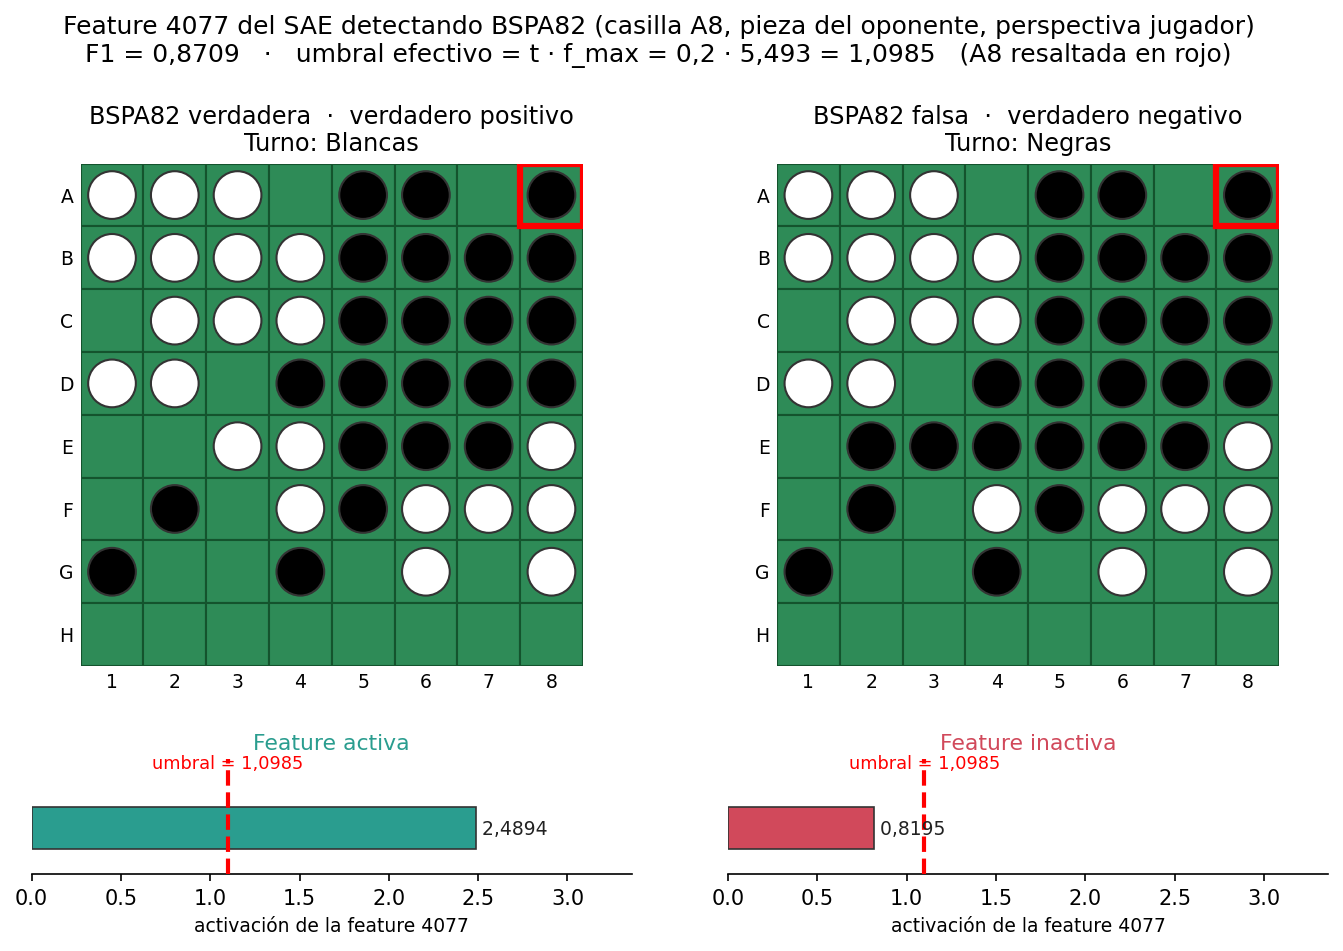

In [10]:
plt.rcParams['figure.dpi'] = 150   # mas nitidez en la vista inline del notebook

fig = plt.figure(figsize=(9.5, 6.4))
gs = fig.add_gridspec(2, 2, height_ratios=[5, 1.15],
                      hspace=0.30, wspace=0.16,
                      top=0.83, bottom=0.09, left=0.06, right=0.97)

paneles = [
    ('BSPA82 verdadera', est_v),
    ('BSPA82 falsa',     est_f),
]

# Escala comun para que el umbral quede en la misma posicion en ambos medidores
xmax_comun = max(est_v['act'], est_f['act'], umbral_efectivo) * 1.35 + 1e-6

for col, (titulo, e) in enumerate(paneles):
    ax_b = fig.add_subplot(gs[0, col])
    dibujar_tablero(ax_b, e['board'])
    supera = e['act'] > umbral_efectivo
    if e['verdadera'] and supera:
        veredicto = 'verdadero positivo'
    elif (not e['verdadera']) and (not supera):
        veredicto = 'verdadero negativo'
    elif e['verdadera'] and not supera:
        veredicto = 'falso negativo'
    else:
        veredicto = 'falso positivo'
    turno = 'Negras' if e['color'] == 1 else 'Blancas'
    ax_b.set_title(f'{titulo}  ·  {veredicto}\nTurno: {turno}',
                   fontsize=11.5, fontweight='normal', pad=6)

    ax_m = fig.add_subplot(gs[1, col])
    dibujar_medidor(ax_m, e['act'], umbral_efectivo, xmax=xmax_comun)

fig.suptitle(
    f'Feature {FEATURE} del SAE detectando {BSP} '
    f'(casilla {CASILLA}, pieza del oponente, perspectiva jugador)\n'
    f'F1 = {fmt(f1_bsp)}   ·   umbral efectivo = t · f_max = '
    f'{fmt(t_rel, 1)} · {fmt(f_max, 3)} = {fmt(umbral_efectivo)}   '
    f'(A8 resaltada en rojo)',
    fontsize=12, fontweight='normal', y=0.985,
)

# Guardar en calidad exportable (PNG 400 dpi) junto al notebook
out_base = Path('.').resolve() / f'feature{FEATURE}_{BSP}_ejemplo'
fig.savefig(out_base.with_suffix('.png'), dpi=400, bbox_inches='tight')
print('Figura guardada en:')
print(' ', out_base.with_suffix('.png'))
plt.show()